/home/sijingdu/.local/share/uv/python/cpython-3.12.9-linux-x86_64-gnu/lib/python3.12/importlib/__init__.py:90: FutureWarning: The module 'quimb.tensor.tensor_arbgeom' is deprecated and will be removed in a future release. Most functionality can be still be accessed directly from 'quimb.tensor' instead. The actual implementations have moved to `quimb.tensor.tnag.core`.
  return _bootstrap._gcd_import(name[level:], package, level)


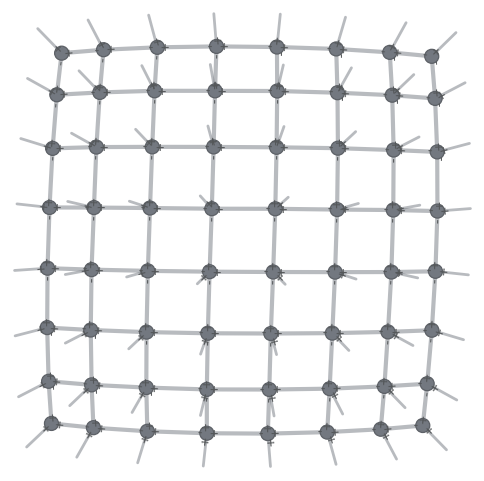

In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ["OMP_NUM_THREADS"] = '1'
import numpy as np
import quimb as qu
import quimb.tensor as qtn

import symmray as sr

import torch

Lx = 8
Ly = 8
nsites = Lx * Ly
D = 8
chi = 4*D
seed = 42
# only the flat backend is compatible with jax.jit
flat = True

# batchsize
B = 1

peps = sr.networks.PEPS_fermionic_rand(
    "Z2",
    Lx,
    Ly,
    D,
    phys_dim=[
        (0, 0),  # linear index 0 -> charge 0, offset 0
        (1, 1),  # linear index 1 -> charge 1, offset 1
        (1, 0),  # linear index 2 -> charge 1, offset 0
        (0, 1),  # linear index 3 -> charge 0, offset 1
    ],
    subsizes="equal",
    flat=flat,
    seed=seed,
    dtype='float64'
)
peps.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.float64))
peps.draw()

In [4]:
# get pytree of initial parameters, and reference tn structure
params, skeleton = qtn.pack(peps)

def get_amp_tn(x, params):
    tn = qtn.unpack(params, skeleton)

    # might need to specify the right site ordering here
    tnx = tn.isel({tn.site_ind(site): x[i] for i, site in enumerate(tn.sites)})

    return tnx
def amplitude(x, params):
    tn = qtn.unpack(params, skeleton)

    # might need to specify the right site ordering here
    tnx = tn.isel({tn.site_ind(site): x[i] for i, site in enumerate(tn.sites)})

    return tnx.contract_hotrg(
        max_bond=chi,
        cutoff=0.0,
        # these two options make the return value (mantissa, exponent)
        # which can avoid issues with small/large values and stability
        equalize_norms=1.0,
        final_contract_opts=dict(strip_exponent=True),
    )
    # tnx.contract_boundary_from_xmin_(max_bond=chi, cutoff=0.0, xrange=[0, Lx//2-1], equalize_norms=1.0)
    # tnx.contract_boundary_from_xmax_(max_bond=chi, cutoff=0.0, xrange=[Lx//2, Lx-1], equalize_norms=1.0)

    # return tnx.contract(strip_exponent=True)

    amp = tnx.contract()
    return amp, amp

In [2]:
# generate half-filling configs
rng = np.random.default_rng(seed)
xs = np.concatenate(
    [
        np.zeros((B, nsites // 2), dtype=np.int32),
        np.ones((B, nsites // 2), dtype=np.int32),
    ],
    axis=1,
)
xs = rng.permuted(xs, axis=1)
xs = torch.tensor(xs, dtype=torch.int32)

In [ ]:
amp_tn = get_amp_tn(xs[0], params)
amp_tn.draw()

First test non eager version:

In [53]:
mantissa, exponent = amplitude(xs[0], params)
print(mantissa, exponent)

tensor(-1., dtype=torch.float64) tensor(35.3700, dtype=torch.float64)


Then test version with torch, gpu tensors:

In [54]:
import torch

# torch.set_default_device("cuda:0")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# convert bitstrings and arrays to torch
xs_gpu = xs.to(device)
params_gpu = qu.tree_map(
    lambda x: x.to(device),
    params,
)

In [56]:
mantissa_gpu, exponent_gpu = amplitude(xs_gpu[0], params_gpu)
print(mantissa_gpu, exponent_gpu)

tensor(-1., device='cuda:0', dtype=torch.float64) tensor(35.3700, device='cuda:0', dtype=torch.float64)


In [73]:
%%timeit
mantissa, exponent = amplitude(xs[0], params)
mantissa, exponent

336 ms ± 26 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [74]:
%%timeit
mantissa_gpu, exponent_gpu = amplitude(xs_gpu[0], params_gpu)
mantissa_gpu, exponent_gpu

1.28 s ± 23.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Then test and warm up torch vmapped version:

In [48]:
vf = torch.vmap(
    amplitude,
    # batch on configs, not parameters
    in_dims=(0, None),
)

In [49]:
%%time
# warmup time
vf(xs_gpu, params_gpu)

CPU times: user 1min 15s, sys: 3.85 s, total: 1min 19s
Wall time: 1min 19s


KeyboardInterrupt: 

In [28]:
%%time
# warmup time
vf(xs, params)

CPU times: user 18.7 s, sys: 73.6 ms, total: 18.8 s
Wall time: 2.05 s


(tensor([-2.7629e+21,  3.6113e+22,  5.9241e+22,  ...,  6.2849e+22,
         -4.3745e+21,  1.6519e+22], dtype=torch.float64),
 tensor([-2.7629e+21,  3.6113e+22,  5.9241e+22,  ...,  6.2849e+22,
         -4.3745e+21,  1.6519e+22], dtype=torch.float64))

In [21]:
%%timeit
# final time (to compute full batch)
vf(xs, params)

19.7 s ± 230 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Using `torch.nn.Module`

Here we wrap the pure function in as a torch module, this enables various
functionality, such as training and exporting it.

In [10]:
class TNAmplitudeModel(torch.nn.Module):
    def __init__(self, fn, tn, vmap=False, **kwargs):
        import quimb as qu
        import quimb.tensor as qtn

        super().__init__()

        # split into plain arrays and bare tn structure
        params, skeleton = qtn.pack(tn)
        # for torch, further flatten pytree into a single list
        params_flat, params_pytree = qu.utils.tree_flatten(
            params, get_ref=True
        )
        # register the flat list parameters
        self.params = torch.nn.ParameterList(
            [torch.as_tensor(x, dtype=torch.float32) for x in params_flat]
        )

        def amplitude(x):
            params = qu.utils.tree_unflatten(self.params, params_pytree)
            tn = qtn.unpack(params, skeleton)
            return fn(x, tn, **kwargs)

        if vmap:
            self.f = torch.vmap(amplitude)
        else:
            self.f = amplitude

    def forward(self, *args):
        return self.f(*args)

In [11]:
# instantiate the model
model = TNAmplitudeModel(amplitude, peps)

In [12]:
# compute output, with gradients
model.forward(xs[0])

(tensor(1., device='cuda:0', grad_fn=<DivBackward0>),
 tensor(32.6688, device='cuda:0', grad_fn=<AddBackward0>))

In [13]:
# compute output, no gradients
with torch.inference_mode():
    print(model.forward(xs[0]))

(tensor(1., device='cuda:0'), tensor(32.6688, device='cuda:0'))


In [14]:
# instantiate a vmapped model
vmodel = TNAmplitudeModel(amplitude, peps, vmap=True)

In [15]:
# compute batch output, no gradients
with torch.inference_mode():
    print(vmodel.forward(xs))

(tensor([ 1., -1.,  1.,  ..., -1.,  1., -1.], device='cuda:0'), tensor([32.6688, 32.7025, 32.7157,  ..., 32.2940, 32.6343, 32.9307],
       device='cuda:0'))
